In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer # Import SimpleImputer

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

import shap

## 1. Data Loading and Initial Inspection

In [ ]:
# Load the dataset
df = pd.read_csv('/content/fea_table.csv')

# Display the first 5 rows
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Info:")
df.info()

First 5 rows of the dataset:


,NoShow,Branch,country,first_time,RoomType,platform,num_children,Price_SGD,NumAdults,Lead_Time_Days,Length_of_Stay_Days,Estimated_Booking_Value
0,0,Changi,Singapore,Yes,Single,Website,0.0,492.9800,1,237,2,985.960
1,0,Orchard,Indonesia,Yes,King,Website,0.0,1351.2200,2,119,1,1351.220
2,0,Changi,India,Yes,Single,Agent,0.0,923.4540,1,343,4,3693.816
3,1,Orchard,China,Yes,Single,Website,0.0,666.0400,1,30,2,1332.080
4,0,Orchard,Australia,Yes,Queen,Website,0.0,898.2495,1,111,4,3592.998



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97777 entries, 0 to 97776
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   NoShow                   97777 non-null  int64  
 1   Branch                   97777 non-null  object 
 2   country                  97777 non-null  object 
 3   first_time               97777 non-null  object 
 4   RoomType                 97777 non-null  object 
 5   platform                 97777 non-null  object 
 6   num_children             97777 non-null  float64
 7   Price_SGD                97777 non-null  float64
 8   NumAdults                97777 non-null  int64  
 9   Lead_Time_Days           97777 non-null  int64  
 10  Length_of_Stay_Days      97777 non-null  int64  
 11  Estimated_Booking_Value  97777 non-null  float64
dtypes: float64(3), int64(4), object(5)
memory usage: 9.0+ MB


## 2. Data Preprocessing

Here, we will prepare the data for model training. This involves:
- Separating features (X) and the target variable (y).
- Identifying numerical and categorical features.
- Applying one-hot encoding to categorical features.
- Splitting the data into training and testing sets.

In [ ]:
# Define target and features
y = df['NoShow']
X = df.drop('NoShow', axis=1)

# Identify categorical and numerical columns
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

print(f"Categorical features: {list(categorical_features)}")
print(f"Numerical features: {list(numerical_features)}")

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_features), # Impute missing numerical values
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Categorical features: ['Branch', 'country', 'first_time', 'RoomType', 'platform']
Numerical features: ['num_children', 'Price_SGD', 'NumAdults', 'Lead_Time_Days', 'Length_of_Stay_Days', 'Estimated_Booking_Value']

Shape of X_train: (78221, 11)
Shape of X_test: (19556, 11)
Shape of y_train: (78221,)
Shape of y_test: (19556,)


In [ ]:
X_train.head(3)

,Branch,country,first_time,RoomType,platform,num_children,Price_SGD,NumAdults,Lead_Time_Days,Length_of_Stay_Days,Estimated_Booking_Value
90440,Changi,Indonesia,Yes,Single,Website,0.0,402.6105,1,212,1,402.6105
64261,Changi,China,No,King,Website,1.0,897.8305,1,12,2,1795.6610
11201,Changi,China,Yes,King,Website,1.0,923.4540,2,303,3,2770.3620


## 3. Model Training and Evaluation

We will train three types of models: Logistic Regression (as a baseline), XGBoost, and Random Forest. For each model, we will evaluate its performance using various metrics and perform SHAP analysis for feature importance.

### 3.1 Logistic Regression (Baseline Model)

Training Logistic Regression model...
Logistic Regression model trained.

--- Logistic Regression Evaluation ---
Accuracy: 0.7205
Precision: 0.6584
Recall: 0.5128
F1 Score: 0.5765
ROC AUC Score: 0.7372


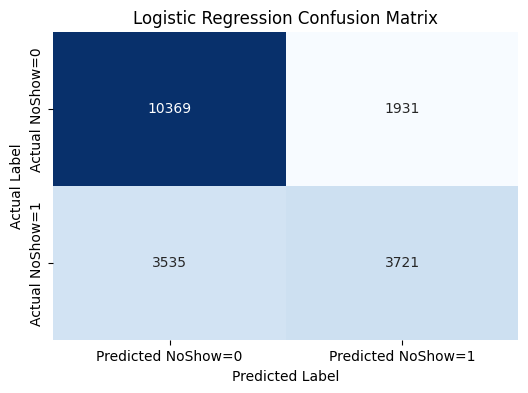

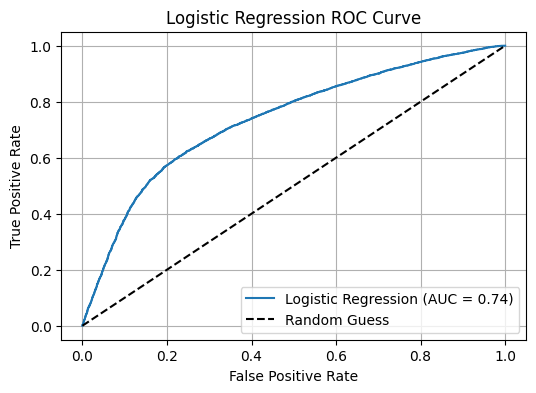

In [ ]:
# Create a pipeline for Logistic Regression
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])

# Train the Logistic Regression model
print("Training Logistic Regression model...")
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Make predictions
y_pred_lr = logistic_pipeline.predict(X_test)
y_prob_lr = logistic_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("\n--- Logistic Regression Evaluation ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1 Score: {f1_lr:.4f}")
print(f"ROC AUC Score: {roc_auc_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted NoShow=0', 'Predicted NoShow=1'],
            yticklabels=['Actual NoShow=0', 'Actual NoShow=1'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend()
plt.grid()
plt.show()

# Store results
results = {'Logistic Regression': {'Accuracy': accuracy_lr, 'Precision': precision_lr, 'Recall': recall_lr, 'F1 Score': f1_lr, 'ROC AUC': roc_auc_lr}}


#### Logistic Regression Interpretability (Coefficients)

For Logistic Regression, we can examine the coefficients to understand the impact of each feature on the likelihood of 'NoShow'. Note that these coefficients are for the *transformed* features after one-hot encoding.


--- Top 10 Most Important Features (Logistic Regression) ---


,Feature,Coefficient,Absolute_Coefficient
9,cat__country_China,1.367767,1.367767
12,cat__country_Japan,-0.618882,0.618882
15,cat__first_time_No,-0.600790,0.600790
10,cat__country_India,-0.430763,0.430763
7,cat__Branch_Orchard,-0.409270,0.409270
8,cat__country_Australia,-0.379003,0.379003
16,cat__first_time_Yes,0.329275,0.329275
20,cat__RoomType_Single,-0.277375,0.277375
2,num__NumAdults,-0.174080,0.174080
14,cat__country_Singapore,-0.153748,0.153748


/tmp/ipykernel_12206/1512358649.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance_lr.head(20), palette='viridis')


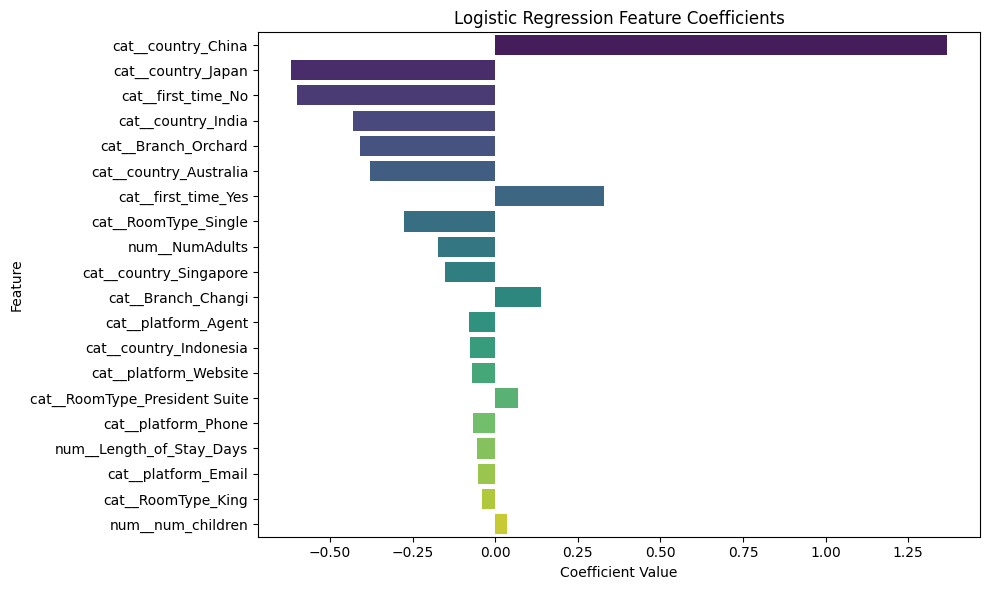

In [ ]:
# Get feature names after preprocessing
preprocessor_output_features = logistic_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get coefficients from the logistic regression model
coefficients = logistic_pipeline.named_steps['classifier'].coef_[0]

# Create a DataFrame for interpretability
feature_importance_lr = pd.DataFrame({'Feature': preprocessor_output_features, 'Coefficient': coefficients})
feature_importance_lr['Absolute_Coefficient'] = np.abs(feature_importance_lr['Coefficient'])
feature_importance_lr = feature_importance_lr.sort_values(by='Absolute_Coefficient', ascending=False)

print("\n--- Top 10 Most Important Features (Logistic Regression) ---")
display(feature_importance_lr.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance_lr.head(20), palette='viridis')
plt.title('Logistic Regression Feature Coefficients')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 3.2 XGBoost Classifier (Main Model)

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:37:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained.

--- XGBoost Evaluation ---
Accuracy: 0.7383
Precision: 0.6907
Recall: 0.5338
F1 Score: 0.6022
ROC AUC Score: 0.7749


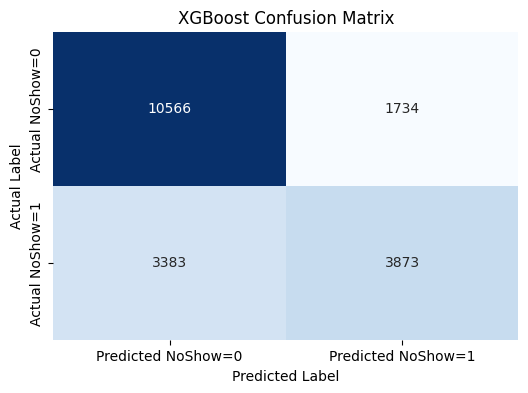

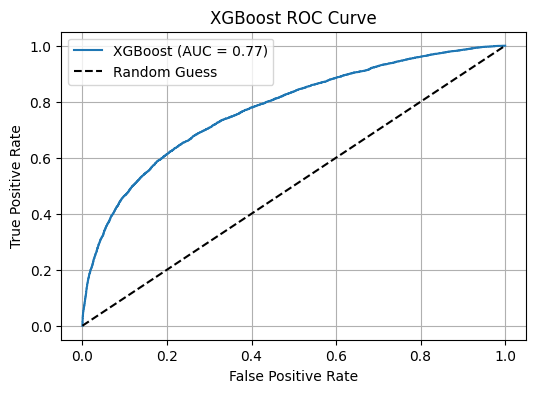

In [ ]:
# Create a pipeline for XGBoost
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Train the XGBoost model
print("Training XGBoost model...")
xgb_pipeline.fit(X_train, y_train)
print("XGBoost model trained.")

# Make predictions
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("\n--- XGBoost Evaluation ---")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1 Score: {f1_xgb:.4f}")
print(f"ROC AUC Score: {roc_auc_xgb:.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted NoShow=0', 'Predicted NoShow=1'],
            yticklabels=['Actual NoShow=0', 'Actual NoShow=1'])
plt.title('XGBoost Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend()
plt.grid()
plt.show()

# Store results
results['XGBoost'] = {'Accuracy': accuracy_xgb, 'Precision': precision_xgb, 'Recall': recall_xgb, 'F1 Score': f1_xgb, 'ROC AUC': roc_auc_xgb}


#### XGBoost Feature Importance with SHAP

SHAP (SHapley Additive exPlanations) is a game theory approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from game theory and their related extensions.


--- SHAP Summary Plot for XGBoost ---


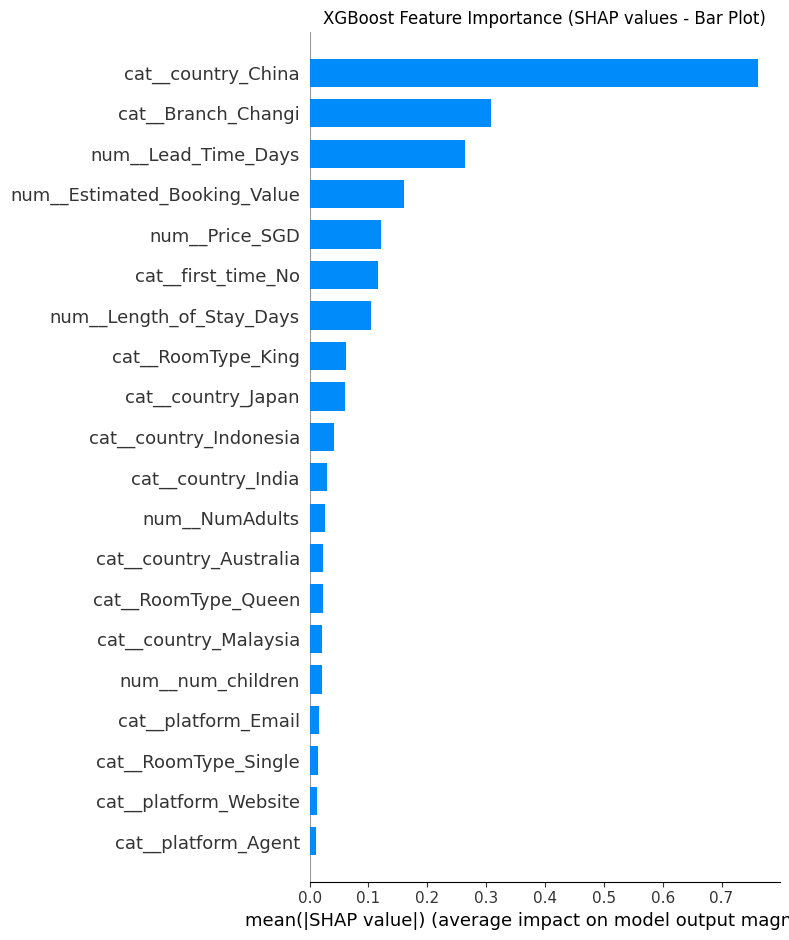

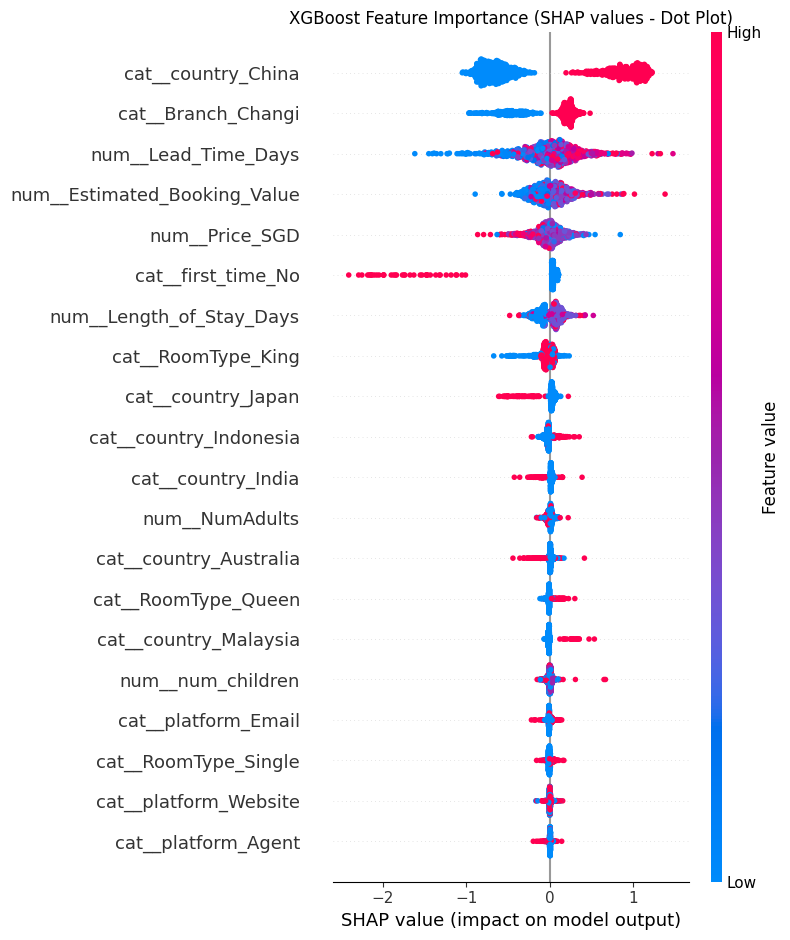

In [ ]:
# Preprocess X_train for SHAP explainer
X_train_processed = xgb_pipeline.named_steps['preprocessor'].transform(X_train)

# Get feature names after preprocessing
feature_names_processed = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame with processed feature names
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_processed)

# Initialize SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_pipeline.named_steps['classifier'])

# Calculate SHAP values for a subset of the training data (for faster computation)
# For full analysis, consider using the entire X_train_processed_df
sampled_indices = np.random.choice(X_train_processed_df.shape[0], 1000, replace=False)
shap_values_xgb = explainer_xgb.shap_values(X_train_processed_df.iloc[sampled_indices])

print("\n--- SHAP Summary Plot for XGBoost ---")
shap.summary_plot(shap_values_xgb, X_train_processed_df.iloc[sampled_indices], plot_type="bar", show=False)
plt.title('XGBoost Feature Importance (SHAP values - Bar Plot)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_xgb, X_train_processed_df.iloc[sampled_indices], show=False)
plt.title('XGBoost Feature Importance (SHAP values - Dot Plot)')
plt.tight_layout()
plt.show()

### 3.3 Random Forest Classifier

Training Random Forest model...
Random Forest model trained.

--- Random Forest Evaluation ---
Accuracy: 0.7059
Precision: 0.6252
Recall: 0.5176
F1 Score: 0.5663
ROC AUC Score: 0.7351


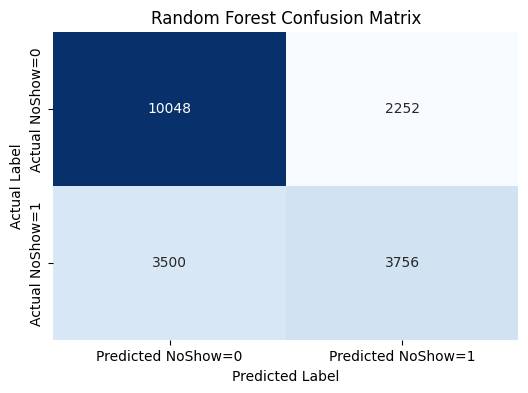

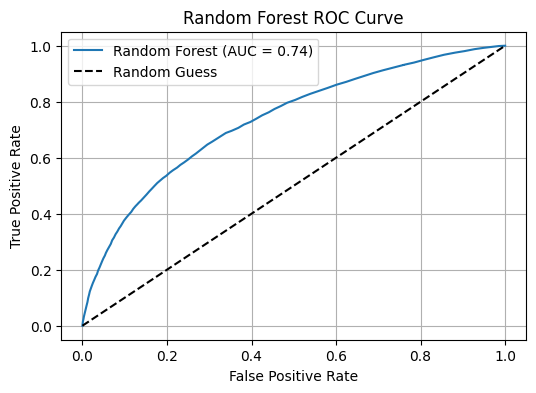

In [ ]:
# Create a pipeline for Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Train the Random Forest model
print("Training Random Forest model...")
rf_pipeline.fit(X_train, y_train)
print("Random Forest model trained.")

# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("\n--- Random Forest Evaluation ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
print(f"ROC AUC Score: {roc_auc_rf:.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted NoShow=0', 'Predicted NoShow=1'],
            yticklabels=['Actual NoShow=0', 'Actual NoShow=1'])
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.grid()
plt.show()

# Store results
results['Random Forest'] = {'Accuracy': accuracy_rf, 'Precision': precision_rf, 'Recall': recall_rf, 'F1 Score': f1_rf, 'ROC AUC': roc_auc_rf}


#### Random Forest Feature Importance with SHAP


--- SHAP Summary Plot for Random Forest ---


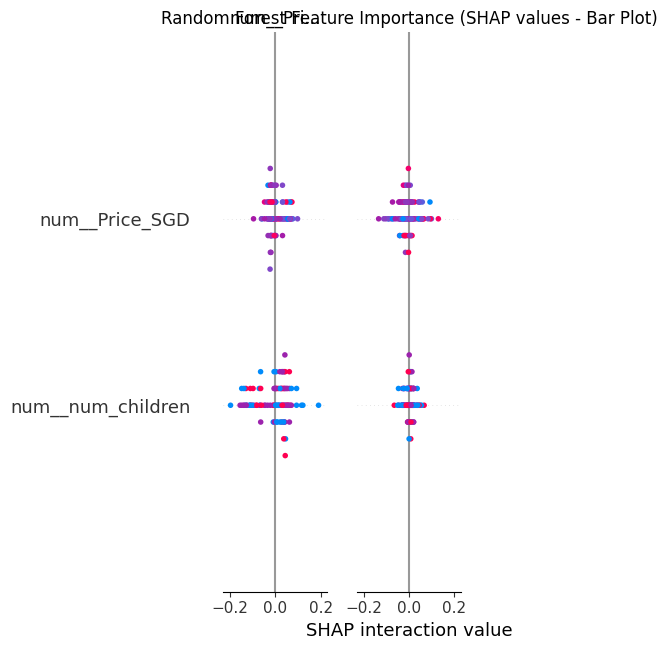

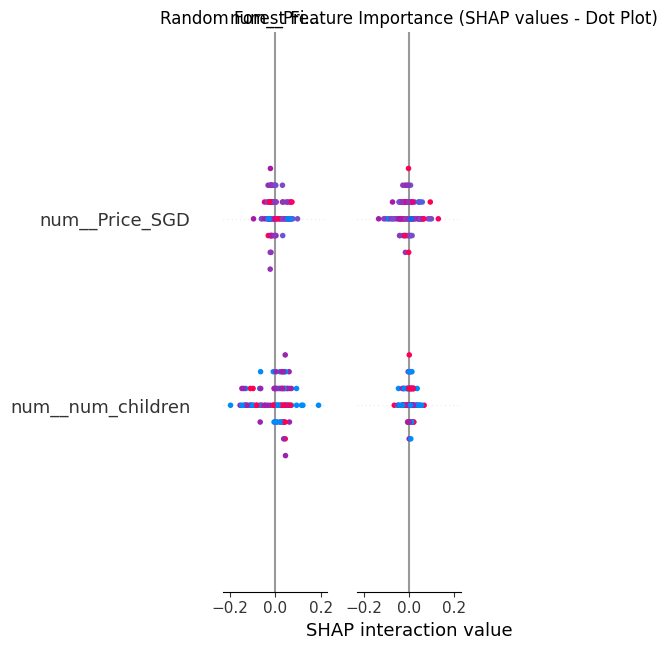

In [ ]:
# Preprocess X_train for SHAP explainer
X_train_processed = rf_pipeline.named_steps['preprocessor'].transform(X_train)

# Get feature names after preprocessing
feature_names_processed = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create a DataFrame with processed feature names
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names_processed)

# Initialize SHAP explainer
explainer_rf = shap.TreeExplainer(rf_pipeline.named_steps['classifier'])

# Calculate SHAP values for a subset of the training data (for faster computation)
sampled_indices = np.random.choice(X_train_processed_df.shape[0], 100, replace=False)
shap_values_rf = explainer_rf.shap_values(X_train_processed_df.iloc[sampled_indices])

# SHAP values for binary classification models often return two arrays (for class 0 and class 1)
# We are interested in the SHAP values for the positive class (class 1)
if isinstance(shap_values_rf, list):
    shap_values_rf = shap_values_rf[1]

print("\n--- SHAP Summary Plot for Random Forest ---")
shap.summary_plot(shap_values_rf, X_train_processed_df.iloc[sampled_indices], plot_type="bar", show=False)
plt.title('Random Forest Feature Importance (SHAP values - Bar Plot)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_rf, X_train_processed_df.iloc[sampled_indices], show=False)
plt.title('Random Forest Feature Importance (SHAP values - Dot Plot)')
plt.tight_layout()
plt.show()

## 4. Model Comparison

Let's compare the performance of the trained models based on the evaluation metrics.


--- Model Comparison ---


,Accuracy,Precision,Recall,F1 Score,ROC AUC
XGBoost,0.738341,0.690744,0.533765,0.602192,0.774914
Logistic Regression,0.720495,0.658351,0.512817,0.576542,0.737193
Random Forest,0.705870,0.625166,0.517641,0.566345,0.735065


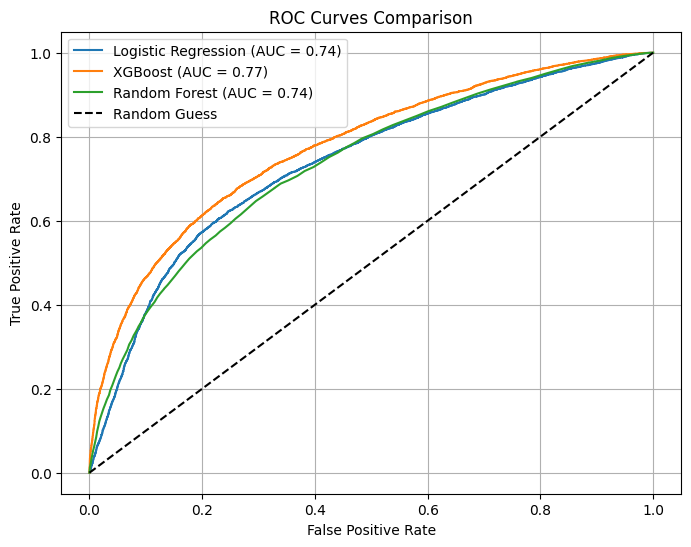

In [ ]:
# Create a DataFrame from the results dictionary
results_df = pd.DataFrame(results).T

print("\n--- Model Comparison ---")
display(results_df.sort_values(by='ROC AUC', ascending=False))

# Plotting ROC Curves for all models
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves Comparison')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# #Logistic Regression
# fpr_lr, tpr_lr
# roc_auc_lr

# #xgboost
# fpr_xgb, tpr_xgb,
# roc_auc_xgb
# #random forest
# fpr_rf, tpr_rf,
# roc_auc_rf

In [ ]:
display(results)

{'Logistic Regression': {'Accuracy': 0.7204949887502556,
  'Precision': 0.6583510261854211,
  'Recall': 0.5128169790518192,
  'F1 Score': 0.576541679578556,
  'ROC AUC': np.float64(0.7371929090363118)},
 'XGBoost': {'Accuracy': 0.7383411740642258,
  'Precision': 0.6907437132156233,
  'Recall': 0.5337651598676957,
  'F1 Score': 0.6021923346031253,
  'ROC AUC': np.float64(0.7749140604691603)},
 'Random Forest': {'Accuracy': 0.7058703211290652,
  'Precision': 0.6251664447403462,
  'Recall': 0.5176405733186329,
  'F1 Score': 0.5663449939686369,
  'ROC AUC': np.float64(0.7350649308450087)}}